# EXPL_02 — Global SHAP Analysis

SHAP complements built-in feature importance by estimating feature
contributions for actual model inputs.

Because Random Forest artifacts are large, SHAP starts with representative
horizons and a reproducible FSA-balanced sample. This is deliberate, not a
shortcut in methodology.


In [1]:
# Import libraries
from pathlib import Path
import sys
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml

In [2]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "explainability.yaml"
CONFIG_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/explainability.yaml')

In [3]:
# Import modules for generating explainability
from src.ontario_peak_risk.explainability.common import (
    load_explainability_config,
    ensure_phase_directories,
    load_final_metadata,
)

In [4]:
# Load parameters
config, project_root = load_explainability_config(CONFIG_PATH)
phase_paths = ensure_phase_directories(config, project_root)
metadata = load_final_metadata(config, project_root)

print("Project root:", project_root)
print("RF:", metadata["rf"]["algorithm"], "| horizons:", metadata["rf"]["horizons"])
print("XGB:", metadata["xgb"]["algorithm"], "| horizons:", metadata["xgb"]["horizons"])
print("Explainability output:", phase_paths["outputs_dir"])


Project root: E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk
RF: RandomForestRegressor | horizons: 24
XGB: XGBoostClassifier | horizons: 24
Explainability output: E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\outputs\explainability


In [5]:
from src.ontario_peak_risk.explainability.data import (
    load_historical_feature_dataset,
    sample_origins,
    build_model_features,
    cap_sample,
)
from src.ontario_peak_risk.explainability.model_access import (
    load_horizon_pipeline,
)
from src.ontario_peak_risk.explainability.shap_analysis import (
    compute_tree_shap,
    feature_value_and_shap_long,
)
from src.ontario_peak_risk.explainability.plotting import (
    shap_global_bar,
    shap_horizon_heatmap,
)
from src.ontario_peak_risk.explainability.reporting import write_shap_report

In [6]:
# Load Historical feature dataset
feature_dataset = load_historical_feature_dataset(config, project_root)
origins = sample_origins(feature_dataset, config)
print("Historical feature dataset:", feature_dataset.shape)
print("Sampled forecast origins:", origins.shape)
display(origins.head())


Historical feature dataset: (262944, 100)
Sampled forecast origins: (240, 2)


,fsa,forecast_origin
0,L4T,2025-01-09 09:00:00
1,L4T,2025-01-17 06:00:00
2,L4T,2025-01-26 21:00:00
3,L4T,2025-01-27 05:00:00
4,L4T,2025-01-31 15:00:00


In [7]:
shap_global_parts = []
shap_long_parts = []

for task in ["rf", "xgb"]:
    task_meta = metadata[task]

    for horizon in config["analysis"]["shap_representative_horizons"]:
        frame = build_model_features(
            task,
            origins,
            feature_dataset,
            horizon,
            task_meta,
        )
        frame = cap_sample(
            frame,
            config["analysis"]["max_shap_rows_per_horizon"],
            config["analysis"]["random_seed"] + int(horizon),
        )

        features = (
            task_meta["numeric_features"]
            + task_meta["categorical_features"]
        )
        X = frame[features].copy()

        print(
            f"{task.upper()} h+{horizon}: "
            f"{len(X)} rows for SHAP"
        )

        pipeline = load_horizon_pipeline(
            task, horizon, config, project_root
        )
        result = compute_tree_shap(
            pipeline,
            X,
            task_meta,
            config,
            task=task,
            horizon=horizon,
        )

        shap_global_parts.append(result["global_table"])
        shap_long_parts.append(
            feature_value_and_shap_long(
                X,
                result,
                task=task,
                horizon=horizon,
            )
        )

        # Critical for RF memory use.
        del result, pipeline, X, frame

shap_global = pd.concat(shap_global_parts, ignore_index=True)
shap_long = pd.concat(shap_long_parts, ignore_index=True)

display(shap_global.head(30))


RF h+1: 240 rows for SHAP


e:\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


RF h+6: 240 rows for SHAP
RF h+12: 240 rows for SHAP
RF h+18: 240 rows for SHAP
RF h+24: 240 rows for SHAP
XGB h+1: 240 rows for SHAP
XGB h+6: 240 rows for SHAP
XGB h+12: 240 rows for SHAP
XGB h+18: 240 rows for SHAP
XGB h+24: 240 rows for SHAP


,task,horizon,feature,feature_family,mean_abs_shap,mean_shap
0,rf,1,target_lag_24h,demand_history,2501.377371,813.444538
1,rf,1,target_lag_48h,demand_history,495.045867,179.462540
2,rf,1,origin__Temp (°C),weather,411.992890,-20.932937
3,rf,1,target_lag_168h,demand_history,396.804523,-1.211848
4,rf,1,origin_rolling_mean_24h,demand_history,349.896529,-84.808065
5,rf,1,origin_rolling_std_24h,demand_history,76.623042,-13.147778
6,rf,1,origin__reported_premise_count,context,64.498903,-9.662310
7,rf,1,target_hour,calendar_time,63.002376,-7.896240
8,rf,1,target_hour_sin,calendar_time,60.925976,-11.451280
9,rf,1,fsa,spatial,43.608936,-8.492969


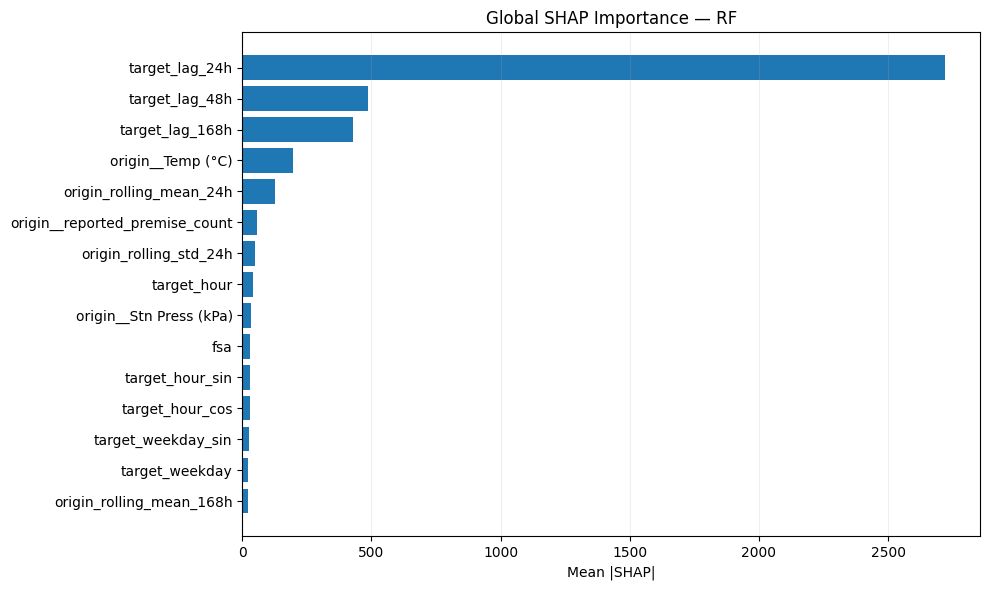

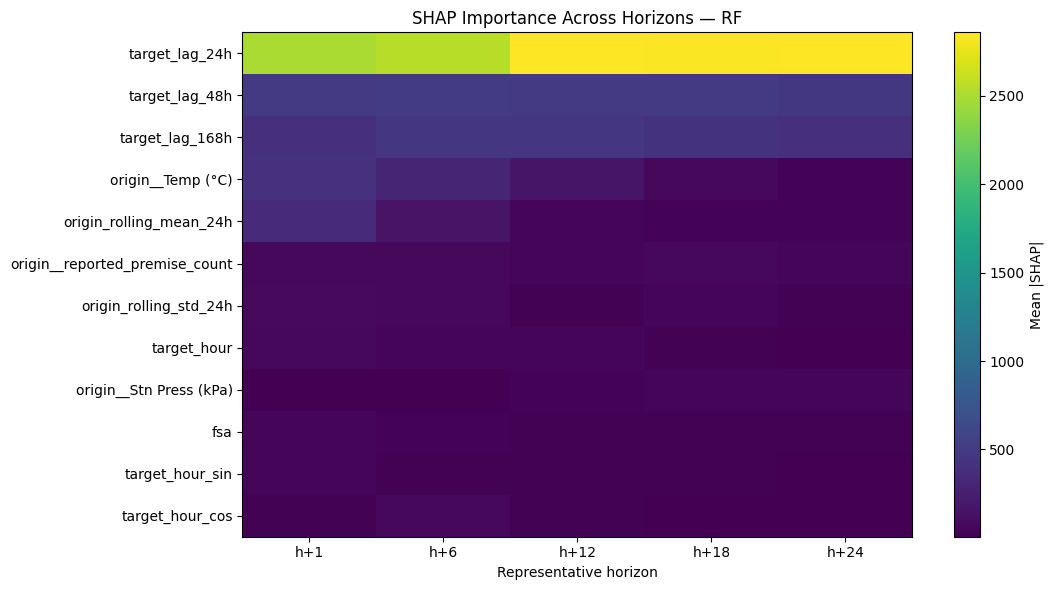

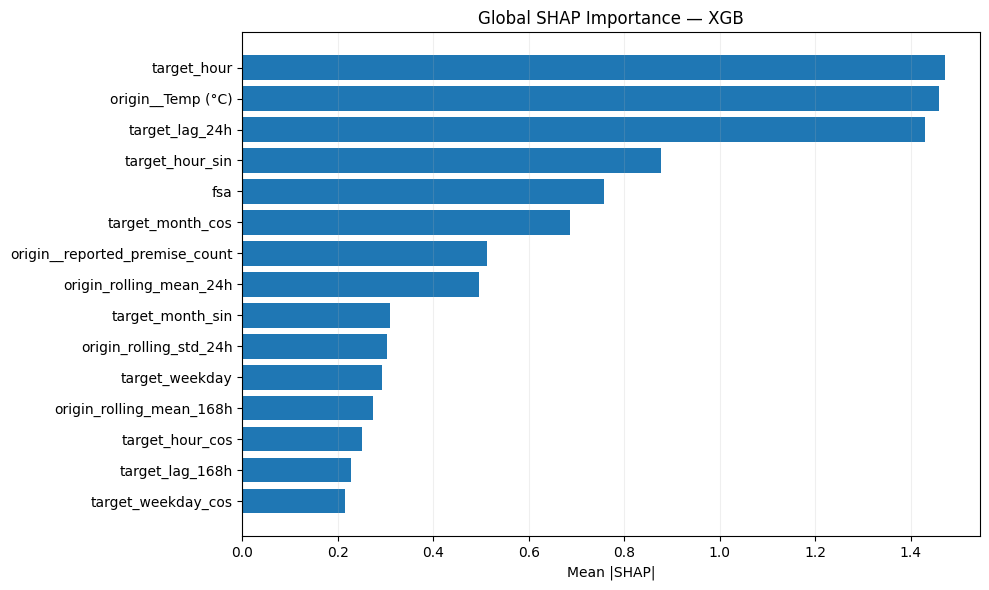

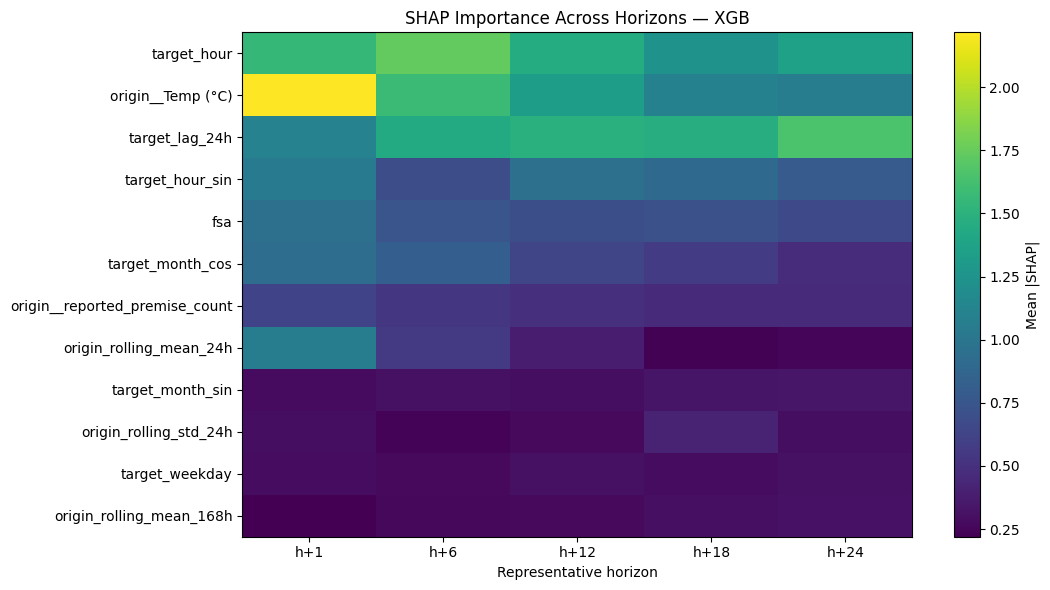

In [8]:
for task in ["rf", "xgb"]:
    shap_global_bar(
        shap_global,
        task,
        top_n=config["analysis"]["top_n_features"],
    )
    plt.show()

    shap_horizon_heatmap(
        shap_global,
        task,
        top_n=12,
    )
    plt.show()


In [22]:
shap_long.head()
print(shap_long.shape)

(52800, 6)


In [24]:
phase_paths["outputs_dir"]

WindowsPath('E:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/outputs/explainability')

In [ ]:
# -------------------------------------------------------------------
# Save SHAP outputs
# -------------------------------------------------------------------
shap_global.to_csv(
    phase_paths["outputs_dir"] / "EXPL_02_shap_global_by_horizon.csv",
    index=False,
)

In [ ]:
#shap_long.to_parquet(
#    phase_paths["outputs_dir"] / "EXPL_02_shap_feature_values.parquet",
#    index=False
#)


In [28]:

# Parquet requires a consistent dtype per column.
# `feature_value` contains both numeric values and categorical values
# such as FSA/season, so preserve both representations explicitly.
shap_long_export = shap_long.copy()

shap_long_export["feature_value_numeric"] = pd.to_numeric(
    shap_long_export["feature_value"],
    errors="coerce",
)

shap_long_export["feature_value_text"] = (
    shap_long_export["feature_value"]
    .astype("string")
)

shap_long_export = shap_long_export.drop(
    columns=["feature_value"]
)

shap_long_export.to_parquet(
    phase_paths["outputs_dir"] / "EXPL_02_shap_feature_values.parquet",
    index=False,
)

print(
    "Saved SHAP rows:",
    f"{len(shap_long_export):,}"
)

Saved SHAP rows: 52,800


In [29]:
write_shap_report(
    phase_paths["docs_dir"] / "EXPL_02_Global_SHAP.md",
    shap_global,
)

In [30]:
print("EXPL_02 RESULT: COMPLETE")


EXPL_02 RESULT: COMPLETE
